## 1. Importing library

In [178]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
print(os.getcwd())

/media/pratama/Data/Other/SELURUH FILE PERKULIAHAN/MATERI SMESTER 6/Data Mining/Projek/projek1/syntax


In [179]:
df = pd.read_csv("../dataset/loan_sanction_train.csv")

## 2. Informasi Dataset

In [180]:
print("Deskripsi statistik")
print(df.describe())

Deskripsi statistik
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  592.000000         600.00000   
mean       5403.459283        1621.245798  146.412162         342.00000   
std        6109.041673        2926.248369   85.587325          65.12041   
min         150.000000           0.000000    9.000000          12.00000   
25%        2877.500000           0.000000  100.000000         360.00000   
50%        3812.500000        1188.500000  128.000000         360.00000   
75%        5795.000000        2297.250000  168.000000         360.00000   
max       81000.000000       41667.000000  700.000000         480.00000   

       Credit_History  
count      564.000000  
mean         0.842199  
std          0.364878  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  


isi dari variabel dependents

In [181]:
df['Dependents'].unique()

<StringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str

In [182]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [183]:
df.isnull().sum()


Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

## 3. Pengecekan Outlier

In [184]:
import pandas as pd

# ambil kolom numerik aja
num_cols = df.select_dtypes(include=['int64', 'float64'])

# hitung Q1, Q3, dan IQR
Q1 = num_cols.quantile(0.25)
Q3 = num_cols.quantile(0.75)
IQR = Q3 - Q1

# filter outlier
outliers = ((num_cols < (Q1 - 1.5 * IQR)) | (num_cols > (Q3 + 1.5 * IQR)))

# tampilkan jumlah outlier per kolom
outliers.sum()


ApplicantIncome      50
CoapplicantIncome    18
LoanAmount           39
Loan_Amount_Term     88
Credit_History       89
dtype: int64

Data yang terdapat missing value tapi juga terdapat outliers 
1. Loan_amount(Jumlah pinjaman yang diajukan), missing value(22), outliers(39)  (tertangani)
2. Loant_Amount_term(jangka waktu pinjaman), missing value (14), outliers(88) (tertangani)
3. Credit history(riwayat credit 1=baik, 0=buruk), missing value (50), outliers(89)

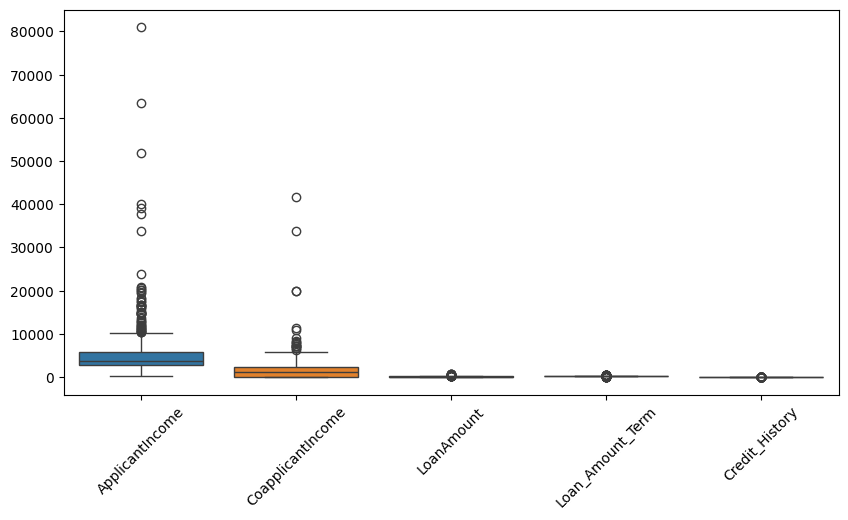

In [185]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(data=num_cols)
plt.xticks(rotation=45)
plt.show()


## 4. penanganan Missing value 

In [ ]:
# Pengisian lount_amount menggunakan mediannya
mean_lount_amount = df['LoanAmount'].median()
df['LoanAmount'] = df['LoanAmount'].fillna(median_lount_amount)
print(f"LoanAmount : {mean_lount_amount}")
# Pengisian lount_amount_term menggunakan modus
mode_term = df['Loan_Amount_Term'].mode()[0]
print(f"Modus loan_term : {mode_term}")
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(mode_term)
# Pengisian credit_history (Tidak termasuk outlier, pengisian menggunakan modus)
mode_credit = df["Credit_History"].mode()[0]
print(f"Modus credit history : {mode_credit}")
df['Credit_History'] = df['Credit_History'].fillna(mode_credit)
# Pengisian gender (Menggunakan modus)
mode_gender = df["Gender"].mode()[0]
print(f"Modus Gender : {mode_gender}")
df['Gender'] = df['Gender'].fillna(mode_gender)
# Pengisian married (Menggunakan modus)
mode_married = df["Married"].mode()[0]
print(f"Modus Married : {mode_married}")
df['Married'] = df['Married'].fillna(mode_married)
# pengisian dependents (menggunakan modus)
df['Dependents'] = df['Dependents'].map({'0': 0, '1': 1,"2": 2, "3+" : 3})
modus_dependents = df['Dependents'].mode()[0]
print(f"Modus Dependents : {modus_dependents} dengan type : {type(modus_dependents)}")
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
# Pengisian Self_employed (menggunkan modus)
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df.isnull().sum()

LoanAmount : 128.0
Modus loan_term : 360.0
Modus credit history : 1.0
Modus Gender : Male
Modus Married : Yes
Modus Dependents : 0.0 dengan type : <class 'numpy.float64'>


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [187]:
df["Dependents"].unique()

array([0., 1., 2., 3.])

Pengecekan Outliers lagi

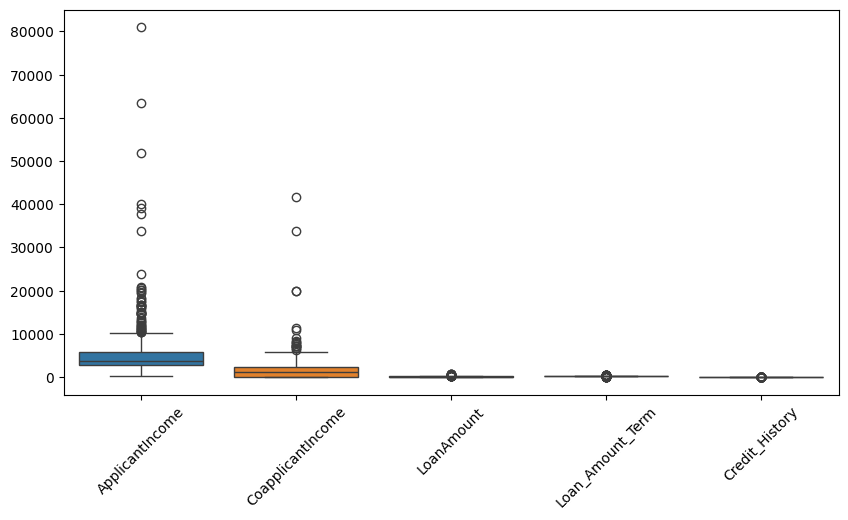

In [188]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(data=num_cols)
plt.xticks(rotation=45)
plt.show()

In [189]:
import pandas as pd

# ambil kolom numerik aja
num_cols = df.select_dtypes(include=['int64', 'float64'])

# hitung Q1, Q3, dan IQR
Q1 = num_cols.quantile(0.25)
Q3 = num_cols.quantile(0.75)
IQR = Q3 - Q1

# filter outlier
outliers = ((num_cols < (Q1 - 1.5 * IQR)) | (num_cols > (Q3 + 1.5 * IQR)))
# tampilkan jumlah outlier per kolom
outliers.sum()

Dependents           51
ApplicantIncome      50
CoapplicantIncome    18
LoanAmount           41
Loan_Amount_Term     88
Credit_History       89
dtype: int64

## 5. Penanganan Outliers

Outlier dapat diatasi dengan 3 cara yang sama seperti penanganan missing value, yakni:

- Leave As It Is (biarkan saja)
- Drop row yang mengandung outliers
- Replace with other values

In [190]:
# Metode pertama kita biarkan saja jadi variabel data tetap df
# Metode kedua kita drop baris yang terdapat outliers
# ambil baris yang ADA outlier
rows_with_outliers = outliers.any(axis=1)

# drop baris yang ada outlier
df_clean_outliers = df[~rows_with_outliers]


In [191]:
df_temp = df.copy()

cols_to_ignore = ["Dependents",'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

while True:
    num_cols = df_temp.select_dtypes(include=['int64', 'float64'])

    # exclude kolom yang nggak mau dicek
    num_cols = num_cols.drop(columns=cols_to_ignore, errors='ignore')

    Q1 = num_cols.quantile(0.25)
    Q3 = num_cols.quantile(0.75)
    IQR = Q3 - Q1

    outliers = ((num_cols < (Q1 - 1.5 * IQR)) |
                (num_cols > (Q3 + 1.5 * IQR)))

    rows_with_outliers = outliers.any(axis=1)

    if rows_with_outliers.sum() == 0:
        break

    df_temp = df_temp[~rows_with_outliers]

df_clean_outliers = df_temp.reset_index(drop=True)


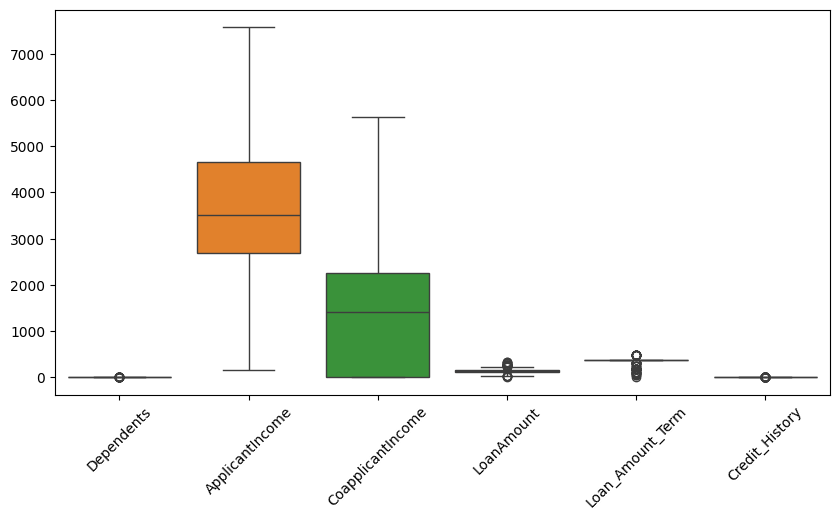

In [192]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(data=df_clean_outliers)
plt.xticks(rotation=45)
plt.show()

In [193]:
df_clean_outliers.info()

<class 'pandas.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            507 non-null    str    
 1   Gender             507 non-null    str    
 2   Married            507 non-null    str    
 3   Dependents         507 non-null    float64
 4   Education          507 non-null    str    
 5   Self_Employed      507 non-null    str    
 6   ApplicantIncome    507 non-null    int64  
 7   CoapplicantIncome  507 non-null    float64
 8   LoanAmount         507 non-null    float64
 9   Loan_Amount_Term   507 non-null    float64
 10  Credit_History     507 non-null    float64
 11  Property_Area      507 non-null    str    
 12  Loan_Status        507 non-null    str    
dtypes: float64(5), int64(1), str(7)
memory usage: 51.6 KB


Replacement outliers with median value

In [194]:
df_outliers_replace = df.copy()

cols = ['ApplicantIncome', 'CoapplicantIncome']

for col in cols:
    Q1 = df_outliers_replace[col].quantile(0.25)
    Q3 = df_outliers_replace[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    median = df_outliers_replace[col].median()

    df_outliers_replace[col] = df_outliers_replace[col].mask(
        (df_outliers_replace[col] < lower) |
        (df_outliers_replace[col] > upper),
        median
    )

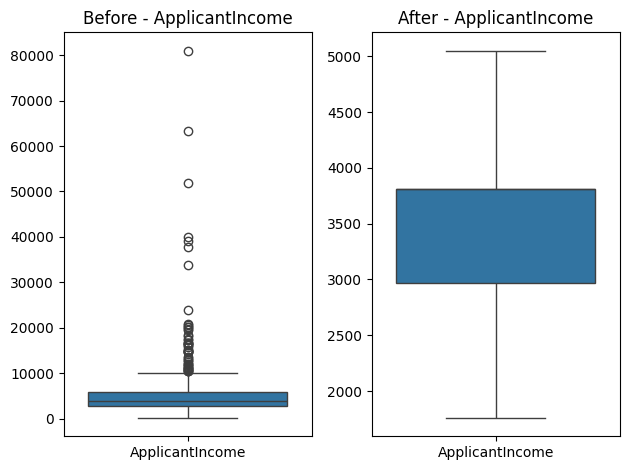

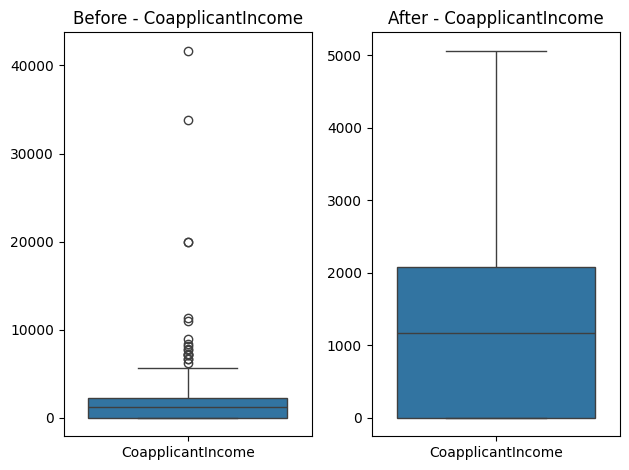

In [195]:
df_outliers_replace = df.copy()

cols = ['ApplicantIncome', 'CoapplicantIncome']

while True:
    num_cols = df_outliers_replace[cols]

    Q1 = num_cols.quantile(0.25)
    Q3 = num_cols.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((num_cols < lower) | (num_cols > upper))

    # cek masih ada outlier atau nggak
    if outliers.sum().sum() == 0:
        break

    for col in cols:
        median = df_outliers_replace[col].median()

        df_outliers_replace[col] = df_outliers_replace[col].mask(
            (df_outliers_replace[col] < lower[col]) |
            (df_outliers_replace[col] > upper[col]),
            median
        )

for col in cols:
    plt.figure()

    plt.subplot(1, 2, 1)
    sns.boxplot(data=df[[col]])
    plt.title(f'Before - {col}')

    plt.subplot(1, 2, 2)
    sns.boxplot(data=df_outliers_replace[[col]])
    plt.title(f'After - {col}')

    plt.tight_layout()
    plt.show()

Hasil pengananan outliers kita ada 3 variabel 
- df_outliers_replace (mereplace outliers dengan nilai tengah sampai bersih)
- df_clean_outliers (manghapus semua baris yang terdapat outliers)
- df (dataset yang dibiarkan terdapa outliers)